# Simulated Annealing

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from tabulate import tabulate

In [34]:
try:
    df = pd.read_csv("sp500_10s.csv")
    print(df.head())
except FileNotFoundError:
    print("Error: The file was not found. Please check the file path.")
except pd.errors.EmptyDataError:
    print("Error: The file is empty.")
except pd.errors.ParserError:
    print("Error: There was a problem parsing the file. Please check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

         date     open     high      low    close     volume  Name
0  2013-02-08  67.7142  68.4014  66.8928  67.8542  158168416  AAPL
1  2013-02-11  68.0714  69.2771  67.6071  68.5614  129029425  AAPL
2  2013-02-12  68.5014  68.9114  66.8205  66.8428  151829363  AAPL
3  2013-02-13  66.7442  67.6628  66.1742  66.7156  118721995  AAPL
4  2013-02-14  66.3599  67.3771  66.2885  66.6556   88809154  AAPL


In [35]:
#Load the price data of the dataset, as well as clean it
def load_price_data(file_path):
    try:
        df = pd.read_csv(file_path)
        df = df.dropna()
        df['date'] = pd.to_datetime(df['date'])
        pivoted = df.pivot(index='date', columns='Name', values='close')
        returns = pivoted.pct_change().dropna()
        mean_returns = returns.mean()
        cov_matrix = returns.cov()
        return df, pivoted, returns, mean_returns, cov_matrix
    except Exception as e:
        print(f"Error in load_price_data: {e}")
        raise

try:
    df, price_df, returns, mean_returns, cov_matrix = load_price_data("sp500_10s.csv")
except Exception:
    raise SystemExit("Failed to initialise data structures.")

In [36]:
class Heuristic:
    def __init__(self, mean_returns, cov_matrix, price_df, risk_free_rate=0.04/252, max_drawdown=0.25):

        ## Initialize the heuristic optimizer.
        ## Parameters:
        ##    mean_returns (pd.Series): Expected daily returns of assets.
        ##    cov_matrix (pd.DataFrame): Covariance matrix of asset returns.
        ##    price_df (pd.DataFrame): Historical price data of the assets.
        ##    risk_free_rate (float): Daily risk-free rate (default: 0.04 annualized).
        ##    max_drawdown (float): Maximum allowable portfolio drawdown.

        self.mean_returns = mean_returns
        self.cov_matrix = cov_matrix
        self.price_df = price_df
        self.risk_free_rate = risk_free_rate
        self.max_drawdown = max_drawdown
        self.num_assets = len(mean_returns)

    def evaluate_solution(self, weights):
        ## Evaluate a given portfolio allocation based on Sharpe ratio and drawdown constraints.
        try:
            weights = np.array(weights)
            weights /= np.sum(weights)  # Ensure weights sum to 1
            ret = np.dot(self.mean_returns, weights)
            vol = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            if vol == 0 or self.max_drawdown_constraint(weights) < 0:
                return -np.inf  # Penalise invalid solutions
            return (ret - self.risk_free_rate) / vol  # Sharpe Ratio
        except Exception as e:
            print(f"Error in evaluate_solution: {e}")
            return -np.inf

    def max_drawdown_constraint(self, weights):
        ## Compute the minimum drawdown and compare against the maximum allowed drawdown.
        ## Returns positive value if within bounds, else negative.
        try:
            portfolio_values = (self.price_df * weights).sum(axis=1)
            rolling_max = portfolio_values.cummax()
            drawdowns = (portfolio_values - rolling_max) / rolling_max
            return self.max_drawdown + drawdowns.min()  # Should be >= 0 to be valid
        except Exception as e:
            print(f"Error in max_drawdown_constraint: {e}")
            return -np.inf

    def get_temperature(self, T0, alpha, iter):
        ## Geometric cooling schedule: T = T0 * alpha^iter
        return T0 * (alpha ** iter)

    def portfolio_performance(self, weights):
        ## Compute annualized return, volatility, and Sharpe ratio for given weights.
        try:
            ret = np.dot(weights, self.mean_returns) * 252
            vol = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights))) * np.sqrt(252)
            sharpe = (ret - self.risk_free_rate * 252) / vol
            return ret, vol, sharpe
        except Exception as e:
            print(f"Error in portfolio_performance: {e}")
            return 0, 0, -np.inf

    def simulated_annealing(self, max_iters, T0, alpha):

        ## Perform simulated annealing to optimize portfolio weights.
        ## Parameters:
        ##    max_iters (int): Number of iterations.
        ##    T0 (float): Initial temperature.
        ##    alpha (float): Cooling rate.
        ## Returns:
        ##    Best weights, best score, score trace, temperature trace.

        try:
            current = np.random.dirichlet(np.ones(self.num_assets), size=1)[0]
            current_score = self.evaluate_solution(current)
            best = current.copy()
            best_score = current_score
            trace, temps = [], []

            for i in range(max_iters):
                T = self.get_temperature(T0, alpha, i)
                new = current.copy()

                # Perturb one random weight
                idx = np.random.randint(0, self.num_assets)
                new[idx] += np.random.normal(0, 0.05)
                new = np.clip(new, 0, 1)
                new /= new.sum()  # Normalize again

                score = self.evaluate_solution(new)

                # Accept better solutions or probabilistically accept worse ones
                if score > current_score or np.random.rand() < np.exp((score - current_score) / T):
                    current, current_score = new, score
                    if score > best_score:
                        best, best_score = new, score

                trace.append(current_score)
                temps.append(T)

            return best, best_score, trace, temps
        except Exception as e:
            print(f"Error in simulated_annealing: {e}")
            return None, None, [], []

    def plot_frontier(self, sharpe_weights, min_vol_weights):

        ## Plot the efficient frontier using randomly sampled portfolios, and highlight
        ## the maximum Sharpe and minimum volatility portfolios.

        try:
            results = np.zeros((3, 3000))  # Store volatility, return, Sharpe

            # Generate random portfolios
            for i in range(3000):
                w = np.random.random(self.num_assets)
                w /= np.sum(w)
                ret, vol, sharpe = self.portfolio_performance(w)
                results[0, i], results[1, i], results[2, i] = vol, ret, sharpe

            # Plot the efficient frontier
            plt.figure(figsize=(12, 7))
            plt.scatter(results[0] * 100, results[1] * 100, c=results[2], cmap='viridis', alpha=0.6)
            plt.colorbar(label="Sharpe Ratio")

            # Highlight key portfolios
            best_ret_sharpe, best_vol_sharpe, _ = self.portfolio_performance(sharpe_weights)
            plt.scatter(best_vol_sharpe * 100, best_ret_sharpe * 100, c='red', marker='*', s=250, label="Max Sharpe Ratio")

            best_ret_minvol, best_vol_minvol, _ = self.portfolio_performance(min_vol_weights)
            plt.scatter(best_vol_minvol * 100, best_ret_minvol * 100, c='blue', marker='*', s=250, label="Min Volatility")

            # Plot Capital Market Line
            rf = self.risk_free_rate * 252
            x = np.linspace(0, best_vol_sharpe * 1.2, 100) * 100
            y = (rf + ((best_ret_sharpe - rf) / best_vol_sharpe) * (x / 100)) * 100
            plt.plot(x, y, color='black', linestyle='--', label='Capital Market Line')

            plt.title("Efficient Frontier (SA)")
            plt.xlabel("Annualised Volatility (%)")
            plt.ylabel("Annualised Return (%)")
            plt.legend()
            plt.grid(True)
            plt.show()

            # Create weight table
            df = pd.DataFrame({
                "Assets": self.mean_returns.index.tolist(),
                "Max Sharpe (%)": np.round(sharpe_weights * 100, 2),
                "Min Volatility (%)": np.round(min_vol_weights * 100, 2)
            })

            # Display table
            print("## Portfolio Weights")
            print(tabulate(df, headers="keys", tablefmt="github", showindex=False))

            # Show summary statistics
            r1, v1, s1 = self.portfolio_performance(sharpe_weights)
            r2, v2, s2 = self.portfolio_performance(min_vol_weights)
            print("\nPerformance Summary:")
            print(f"Max Sharpe Portfolio:     Return = {r1:.2%}, Volatility = {v1:.2%}, Sharpe Ratio = {s1:.3f}")
            print(f"Min Volatility Portfolio: Return = {r2:.2%}, Volatility = {v2:.2%}, Sharpe Ratio = {s2:.3f}")
        except Exception as e:
            print(f"Error in plot_frontier: {e}")

    def print_performance(self, weights):
        ## Print portfolio performance metrics for a given set of weights.
        try:
            ret, vol, sharpe = self.portfolio_performance(weights)
            print(f"Return: {ret:.2f}%, Volatility: {vol:.2f}%, Sharpe Ratio: {sharpe:.3f}")
        except Exception as e:
            print(f"Error in print_performance: {e}")

In [37]:
# Run the algorithm, and obtain the best scores, temperature traces and fitness of portfolio over iteration
try:
    h = Heuristic(mean_returns, cov_matrix, price_df)
    best_weights, best_score, trace, temps = h.simulated_annealing(1500, 100, 0.999)
except Exception as e:
    raise SystemExit(f"Error running Simulated Annealing: {e}")

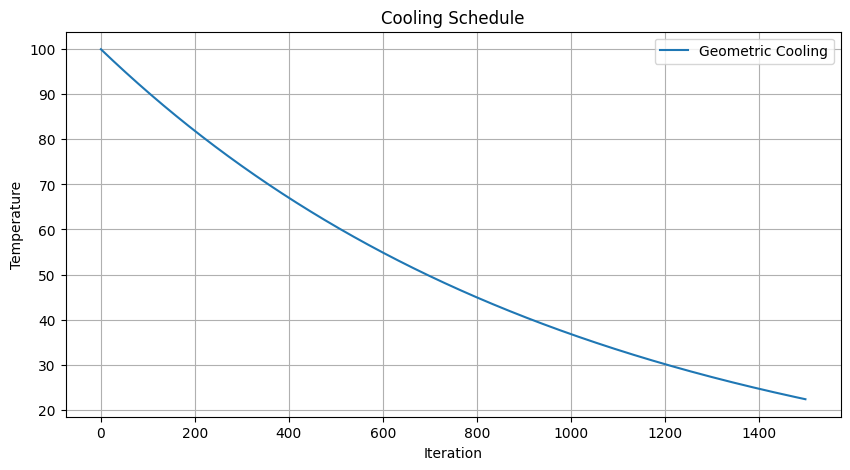

In [38]:
# Plot temperature cooling schedule
try:
    plt.figure(figsize=(10, 5))
    plt.plot(temps, label="Geometric Cooling")
    plt.title("Cooling Schedule")
    plt.xlabel("Iteration")
    plt.ylabel("Temperature")
    plt.grid(True)
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Error plotting temperature: {e}")

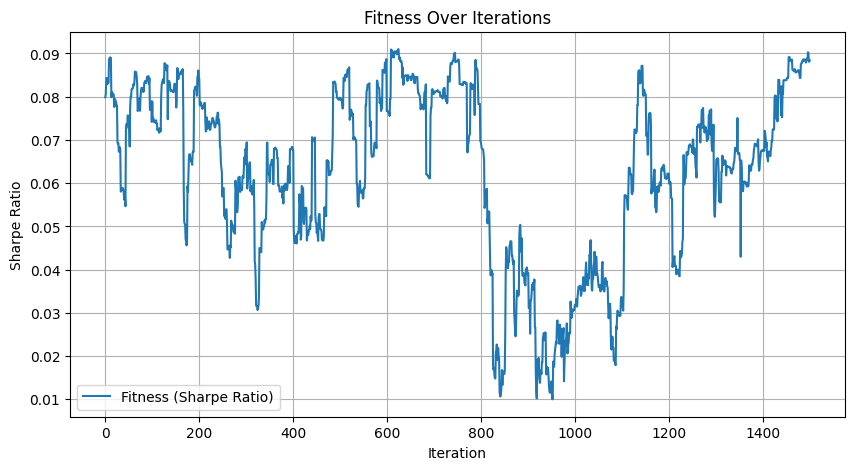

In [39]:
#Plotting the fitness graph
try:
    plt.figure(figsize=(10, 5))
    plt.plot(trace, label="Fitness (Sharpe Ratio)")
    plt.title("Fitness Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Sharpe Ratio")
    plt.grid(True)
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Error plotting fitness: {e}")

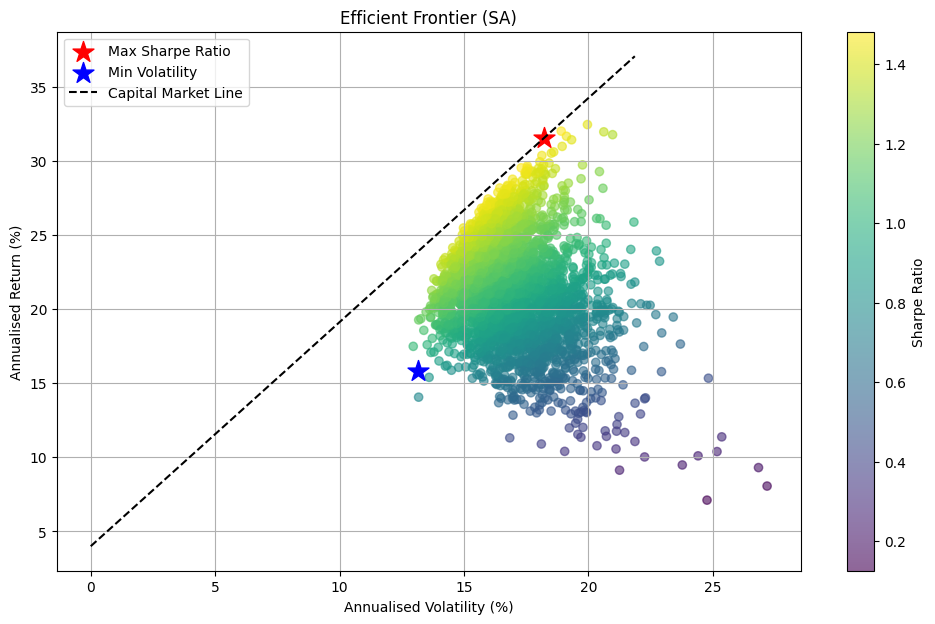

## Portfolio Weights
| Assets   |   Max Sharpe (%) |   Min Volatility (%) |
|----------|------------------|----------------------|
| AAPL     |            18.17 |                24.49 |
| AMZN     |            18.56 |                 4.16 |
| BAC      |             5.54 |                10.13 |
| CHK      |             0    |                 3.05 |
| GOOGL    |             3.84 |                 8.32 |
| JNJ      |             3.3  |                14.98 |
| MSFT     |            12.11 |                 5.14 |
| NFLX     |            19.88 |                 0    |
| V        |            16.09 |                 0    |
| WMT      |             2.52 |                29.73 |

Performance Summary:
Max Sharpe Portfolio:     Return = 31.56%, Volatility = 18.22%, Sharpe Ratio = 1.512
Min Volatility Portfolio: Return = 15.83%, Volatility = 13.17%, Sharpe Ratio = 0.898


In [40]:
# Run Simulated Annealing for Max Sharpe Ratio
try:
    best_sharpe_weights, sharpe_score, trace_sharpe, temps_sharpe = h.simulated_annealing(
        max_iters=1500, T0=100, alpha=0.999
    )

    # Temporarily change evaluation to minimise volatility
    original_eval = h.evaluate_solution
    h.evaluate_solution = lambda w: -np.sqrt(np.dot(w.T, np.dot(h.cov_matrix, w)))

    # Run Simulated Annealing for Min Volatility
    best_minvol_weights, _, trace_minvol, temps_minvol = h.simulated_annealing(
        max_iters=1500, T0=100, alpha=0.999
    )

    # Restore original evaluation function
    h.evaluate_solution = original_eval

    # Plot the Efficient Frontier with both solutions
    h.plot_frontier(best_sharpe_weights, best_minvol_weights)

except Exception as e:
    print(f"Error during max Sharpe / min volatility SA runs: {e}")